In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


# EDA :

In [ ]:
df = pd.read_csv('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [12]:
print("Columns:", df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing Values:
customerID          0
gender       

# Churn Distribution

Churn Count:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


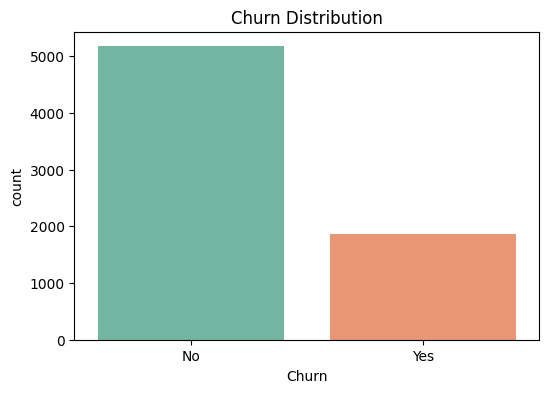

In [7]:
print("Churn Count:")
print(df['Churn'].value_counts())
print("\nChurn Percentage:")
print(df['Churn'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Churn Distribution')
plt.show()

# Churn by Contract Type

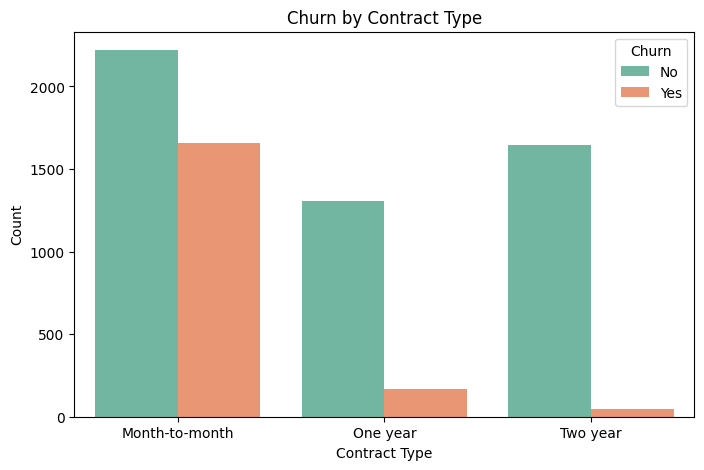

In [8]:
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn', data=df, palette='Set2')
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.show()

# Tenure vs Churn

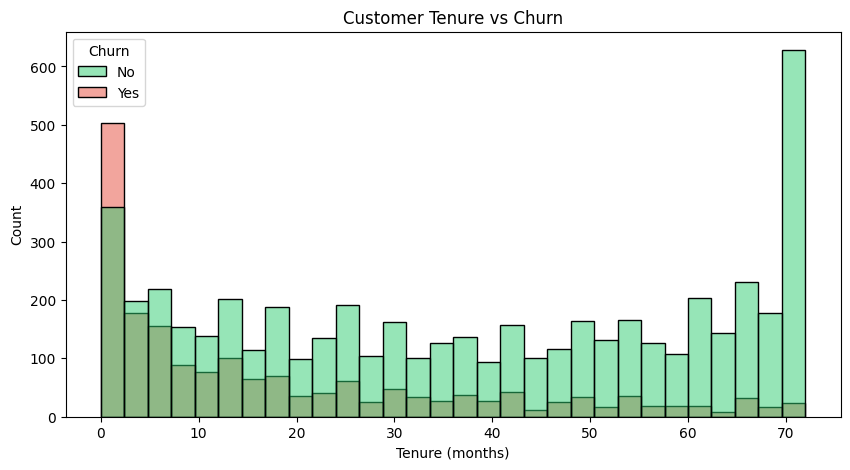

In [9]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30,
             palette={'No':'#2ecc71','Yes':'#e74c3c'})
plt.title('Customer Tenure vs Churn')
plt.xlabel('Tenure (months)')
plt.ylabel('Count')
plt.show()

# Monthly Charges vs Churn

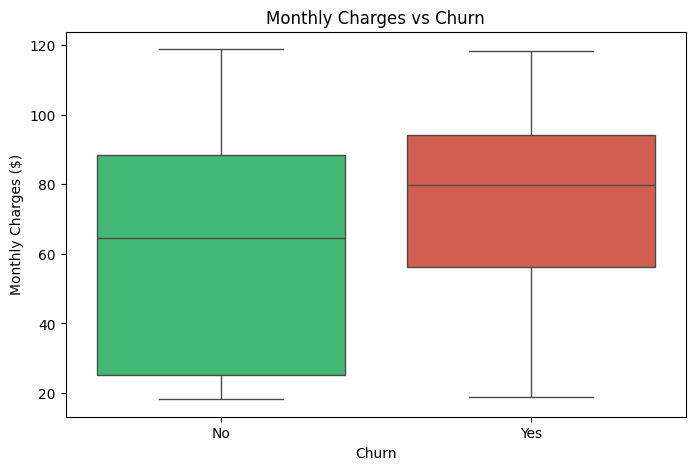

In [10]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df,
            palette={'No':'#2ecc71','Yes':'#e74c3c'})
plt.title('Monthly Charges vs Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges ($)')
plt.show()

# Correlation Heatmap

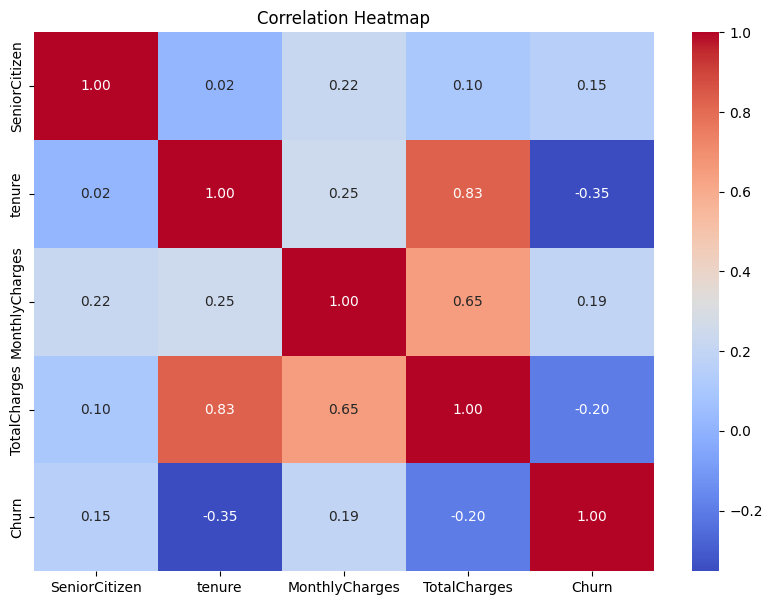

In [11]:
df_corr = df.copy()
df_corr['Churn'] = df_corr['Churn'].map({'Yes':1,'No':0})
df_corr['TotalCharges'] = pd.to_numeric(df_corr['TotalCharges'], errors='coerce')

numeric_df = df_corr.select_dtypes(include=[np.number])
plt.figure(figsize=(10,7))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# EDA is Done! 

# Data Preprocessing

#  Fix Data Types & Missing Values

In [13]:
# Fix TotalCharges column
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Drop customerID (not useful)
df = df.drop('customerID', axis=1)

# Convert Churn to 0 and 1
df['Churn'] = df['Churn'].map({'Yes':1,'No':0})

print("Fixed! Missing values now:", df.isnull().sum().sum())
print("Shape:", df.shape)

Fixed! Missing values now: 0
Shape: (7043, 20)


# Label Encoding

In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
binary_cols = ['gender','Partner','Dependents','PhoneService',
               'PaperlessBilling','MultipleLines']

for col in binary_cols:
    df[col] = le.fit_transform(df[col])

print("Label Encoding Done!")
print(df[binary_cols].head())

Label Encoding Done!
   gender  Partner  Dependents  PhoneService  PaperlessBilling  MultipleLines
0       0        1           0             0                 1              1
1       1        0           0             1                 0              0
2       1        0           0             1                 1              0
3       1        0           0             0                 0              1
4       0        0           0             1                 1              0


# One Hot Encoding

In [15]:
df = pd.get_dummies(df, columns=[
    'InternetService','Contract','PaymentMethod',
    'OnlineSecurity','OnlineBackup','DeviceProtection',
    'TechSupport','StreamingTV','StreamingMovies'
])

print("One Hot Encoding Done!")
print("New Shape:", df.shape)
print("New Columns:", df.columns.tolist())

One Hot Encoding Done!
New Shape: (7043, 39)
New Columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'OnlineSecurity_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No', 'StreamingMovies_No internet service', 'StreamingMovies_Yes']


# Feature Engineering

In [16]:
df['AvgMonthlySpend'] = df['TotalCharges'] / (df['tenure'] + 1)
df['NumServices'] = (
    df['PhoneService'] +
    df['StreamingTV_Yes'] +
    df['StreamingMovies_Yes'] +
    df['OnlineSecurity_Yes']
)

print("New Features Created!")
print("Final Shape:", df.shape)
df[['AvgMonthlySpend','NumServices']].head()

New Features Created!
Final Shape: (7043, 41)


,AvgMonthlySpend,NumServices
0,14.925000,0
1,53.985714,2
2,36.050000,2
3,40.016304,1
4,50.550000,1


# Train Test Split

In [17]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print("\nChurn % in train:", round(y_train.mean()*100, 2), "%")
print("Churn % in test:", round(y_test.mean()*100, 2), "%")

X_train shape: (5634, 40)
X_test shape: (1409, 40)
y_train shape: (5634,)
y_test shape: (1409,)

Churn % in train: 26.54 %
Churn % in test: 26.54 %


# SMOTE

In [20]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())
print("\nAfter SMOTE:")
print(pd.Series(y_train_res).value_counts())
print("\nNow both classes are equal!")

Before SMOTE:
Churn
0    4139
1    1495
Name: count, dtype: int64

After SMOTE:
Churn
0    4139
1    4139
Name: count, dtype: int64

Now both classes are equal!


# Train All Models

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42)
}

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    print(f"\n===== {name} =====")
    print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
    print(classification_report(y_test, y_pred))


===== Logistic Regression =====
ROC-AUC: 0.8386
              precision    recall  f1-score   support

           0       0.86      0.86      0.86      1035
           1       0.61      0.60      0.61       374

    accuracy                           0.79      1409
   macro avg       0.73      0.73      0.73      1409
weighted avg       0.79      0.79      0.79      1409


===== Random Forest =====
ROC-AUC: 0.8200
              precision    recall  f1-score   support

           0       0.84      0.85      0.85      1035
           1       0.57      0.56      0.57       374

    accuracy                           0.77      1409
   macro avg       0.71      0.70      0.71      1409
weighted avg       0.77      0.77      0.77      1409


===== XGBoost =====
ROC-AUC: 0.8247
              precision    recall  f1-score   support

           0       0.84      0.87      0.85      1035
           1       0.60      0.56      0.58       374

    accuracy                           0.78      1409

# Hyperparameter Tuning

In [22]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

xgb = XGBClassifier(eval_metric='logloss', random_state=42)
grid = GridSearchCV(xgb, param_grid, cv=5,
                    scoring='roc_auc', n_jobs=-1, verbose=1)
grid.fit(X_train_res, y_train_res)

print("Best Params:", grid.best_params_)
print("Best ROC-AUC:", grid.best_score_)
best_model = grid.best_estimator_

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Best ROC-AUC: 0.9407445311878504


# Confusion Matrix : No      Yes
#    Actual   No    [ TN  |  FP ]
#             Yes   [ FN  |  TP ]

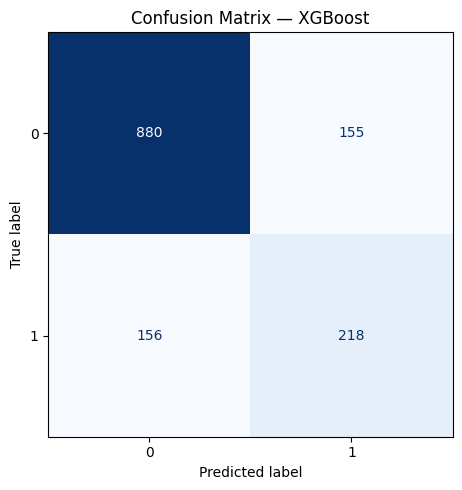

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay.from_estimator(
    best_model, X_test, y_test,
    ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — XGBoost')
plt.tight_layout()
plt.show()

# SHAP Explainability

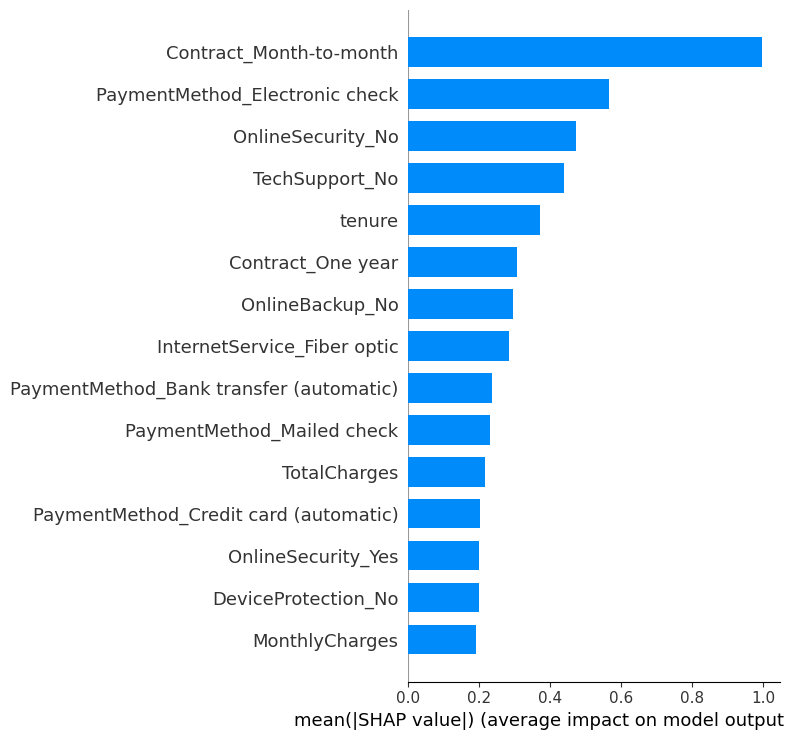

In [25]:
import shap

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Feature Importance
shap.summary_plot(shap_values, X_test, 
                  plot_type='bar', max_display=15)

# beeswarm chart 

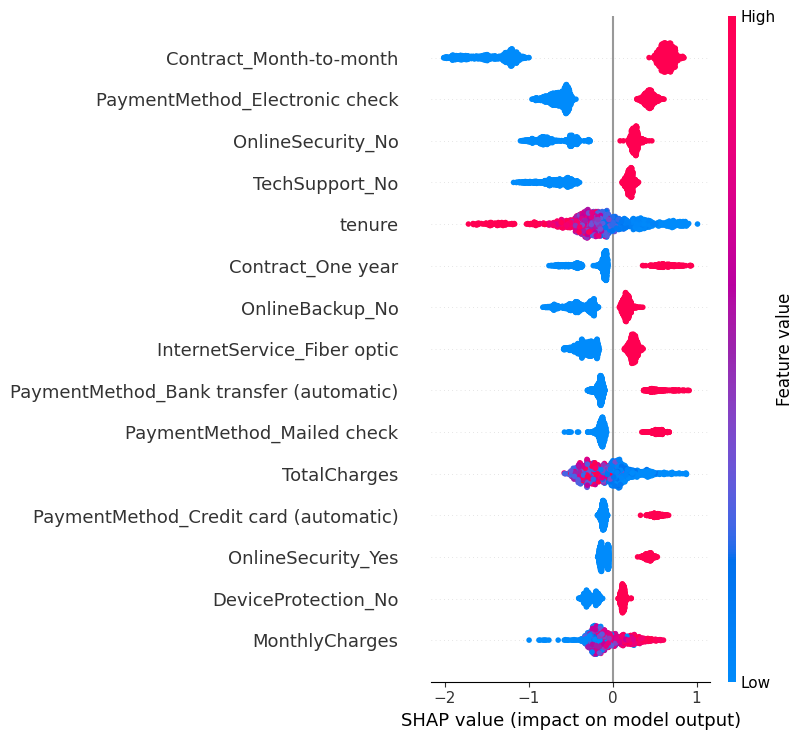

In [26]:
# Beeswarm plot - shows direction too!
shap.summary_plot(shap_values, X_test, 
                  max_display=15)

# SAVING THE MODEL 

In [29]:
import joblib
import os

# Use full path directly
os.makedirs('C:/Users/j9698/OneDrive/Desktop/churn-prediction/models', exist_ok=True)

joblib.dump(best_model, 'C:/Users/j9698/OneDrive/Desktop/churn-prediction/models/churn_model.pkl')
joblib.dump(X_train.columns.tolist(), 'C:/Users/j9698/OneDrive/Desktop/churn-prediction/models/feature_names.pkl')

print("✅ Model saved successfully!")
print("✅ Feature names saved successfully!")

✅ Model saved successfully!
✅ Feature names saved successfully!
